Vorgehensweise: 

1) Daten laden
2) Daten überprüfen und ggf. bereinigen

3) Berechnungen, Datenanalyse und Visualisierungen für das jeweilige Kapitel


1) Daten laden

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
# Datei aus Unterordner laden
df = pd.read_csv("data/data_in_use/diabetes_binary_health_indicators_BRFSS2015.csv")

# Erste 5 Zeilen anzeigen
df.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


2) Daten überprüfen und ggf. bereinigen

In [5]:
# Anzahl der Datensaätze und Spalten
df.shape

(253680, 22)

In [6]:
# Zeigt Spaltennamen, Anzahl Werte und Datentyp an
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [ ]:
# Spaltennamen auf deutsch übersetzen
# Dictionary für die Übersetzung
uebersetzung = {
    "Diabetes_binary": "Diabetes_Status",
    "HighBP": "Bluthochdruck",
    "HighChol": "Cholesterin_hoch",
    "CholCheck": "Cholesterin_Check",
    "BMI": "BMI",
    "Smoker": "Raucher_Status",
    "Stroke": "Schlaganfall",
    "HeartDiseaseorAttack": "Herzerkrankung_Infarkt",
    "PhysActivity": "Sportliche_Aktivitaet",
    "Fruits": "Obst_Konsum",
    "Veggies": "Gemuese_Konsum",
    "HvyAlcoholConsump": "Hoher_Alkoholkonsum",
    "AnyHealthcare": "Krankenversicherung",
    "NoDocbcCost": "Kein_Arzt_wegen_Kosten",
    "GenHlth": "Allgemeine_Gesundheit",
    "MentHlth": "Psychische_Gesundheit",
    "PhysHlth": "Koerperliche_Gesundheit",
    "DiffWalk": "Einschränkung_Gehen",
    "Sex": "Geschlecht",
    "Age": "Altersgruppe",
    "Education": "Bildungsstand",
    "Income": "Einkommensstufe",
    "BMI_Kategorie_Text": "BMI_Kategorie_Text", 
}

# Spalten im Dataframe umbenennen
df = df.rename(columns=uebersetzung)

# Check
print(df.columns.tolist())

['Diabetes_Status', 'Bluthochdruck', 'Cholesterin_hoch', 'Cholesterin_Check', 'BMI', 'Raucher_Status', 'Schlaganfall', 'Herzerkrankung_Infarkt', 'Sportliche_Aktivitaet', 'Obst_Konsum', 'Gemuese_Konsum', 'Hoher_Alkoholkonsum', 'Krankenversicherung', 'Kein_Arzt_wegen_Kosten', 'Allgemeine_Gesundheit', 'Psychische_Gesundheit', 'Koerperliche_Gesundheit', 'Einschränkung_Gehen', 'Geschlecht', 'Altersgruppe', 'Bildungsstand', 'Einkommensstufe', 'BMI_Kategorie_Text', 'BMI_Kategorie_Code']


In [ ]:
# Liste der float64 Spalten die in int8 umgewandelt werden sollen
int8_spalten = [
    "Diabetes_Status",
    "Bluthochdruck",
    "Cholesterin_hoch",
    "Cholesterin_Check",
    "BMI",  
    "Raucher_Status",
    "Schlaganfall",
    "Herzerkrankung_Infarkt",
    "Sportliche_Aktivitaet",
    "Obst_Konsum",
    "Gemuese_Konsum",
    "Hoher_Alkoholkonsum",
    "Krankenversicherung",
    "Kein_Arzt_wegen_Kosten",
    "Allgemeine_Gesundheit",
    "Psychische_Gesundheit",
    "Koerperliche_Gesundheit",
    "Einschränkung_Gehen",
    "Geschlecht",
    "Altersgruppe",
    "Bildungsstand",
    "Einkommensstufe"
]

# Alle aufgelisteten Spalten in int8 konvertieren
df[int8_spalten] = df[int8_spalten].astype("int8")

In [94]:
df.info()

# 8-Werte-Übersicht pro Spalte
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Status          253680 non-null  int8 
 1   Bluthochdruck            253680 non-null  int8 
 2   Cholesterin_hoch         253680 non-null  int8 
 3   Cholesterin_Check        253680 non-null  int8 
 4   BMI                      253680 non-null  int8 
 5   Raucher_Status           253680 non-null  int8 
 6   Schlaganfall             253680 non-null  int8 
 7   Herzerkrankung_Infarkt   253680 non-null  int8 
 8   Sportliche_Aktivitaet    253680 non-null  int8 
 9   Obst_Konsum              253680 non-null  int8 
 10  Gemuese_Konsum           253680 non-null  int8 
 11  Hoher_Alkoholkonsum      253680 non-null  int8 
 12  Krankenversicherung      253680 non-null  int8 
 13  Kein_Arzt_wegen_Kosten   253680 non-null  int8 
 14  Allgemeine_Gesundheit    253680 non-null  int8 

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Kein_Arzt_wegen_Kosten,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Code
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,2.239597
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,1.134719
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,1.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,2.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,3.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,5.000000


In [119]:
# Check doppelte Werte 
df.duplicated().sum()

np.int64(24206)

In [120]:
 # Zeigt alle Zeilen an, die im Datensatz mehrfach vorkommen
df_duplicates = df[df.duplicated(keep=False)]
df_duplicates

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Text,BMI_Kategorie_Code
5,0,1,1,1,25,1,0,0,1,1,...,2,0,2,0,1,10,6,8,Übergewicht (25.0 - 29.9),2
25,0,0,0,1,32,0,0,0,1,1,...,2,0,0,0,0,5,6,8,Adipositas Grad I (30.0 - 34.9),3
29,0,0,1,1,31,1,0,0,1,1,...,1,0,0,0,1,12,6,8,Adipositas Grad I (30.0 - 34.9),3
44,0,0,1,1,31,1,0,0,0,1,...,2,0,0,0,0,8,5,8,Adipositas Grad I (30.0 - 34.9),3
52,1,1,1,1,27,1,0,0,0,0,...,5,0,30,1,0,10,4,5,Übergewicht (25.0 - 29.9),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1,1,1,1,33,0,0,0,1,1,...,3,0,0,0,1,9,6,6,Adipositas Grad I (30.0 - 34.9),3
253550,0,0,0,1,25,0,0,0,1,1,...,1,0,0,0,0,7,6,8,Übergewicht (25.0 - 29.9),2
253563,0,0,1,1,24,1,0,0,1,1,...,2,0,0,0,1,8,6,8,Normalgewicht (18.5 - 24.9),1
253597,0,0,0,1,24,0,0,0,1,1,...,2,0,0,0,0,5,6,8,Normalgewicht (18.5 - 24.9),1


In [121]:
# Gruppiert alle identischen Zeilen (Profile) und zählt wie oft sie vorkommen
haeufigste_profile = df.value_counts()

# Zeigt die Top 5 der am häufigsten vorkommenden Profile
haeufigste_profile

Diabetes_Status  Bluthochdruck  Cholesterin_hoch  Cholesterin_Check  BMI  Raucher_Status  Schlaganfall  Herzerkrankung_Infarkt  Sportliche_Aktivitaet  Obst_Konsum  Gemuese_Konsum  Hoher_Alkoholkonsum  Krankenversicherung  Kein_Arzt_wegen_Kosten  Allgemeine_Gesundheit  Psychische_Gesundheit  Koerperliche_Gesundheit  Einschränkung_Gehen  Geschlecht  Altersgruppe  Bildungsstand  Einkommensstufe  BMI_Kategorie_Text             BMI_Kategorie_Code
0                0              0                 1                  21   0               0             0                       1                      1            1               0                    1                    0                       1                      0                      0                        0                    0           6             6              8                Normalgewicht (18.5 - 24.9)    1                     59
                                                                     23   0               0           

In [122]:
# Das absolut häufigste Profil ermitteln (Index 0 der sortierten Liste)
haeufigstes_profil_index = df.value_counts().index[0]
haeufigstes_profil_anzahl = df.value_counts().iloc[0]

# Als Tabelle darstellen
df_top_profil = pd.DataFrame([haeufigstes_profil_index], columns=df.columns)

print(f"Dieses Profil kommt exakt {haeufigstes_profil_anzahl} Mal im Datensatz vor:\n")
df_top_profil.T   # .T dreht die Tabelle hochkant

Dieses Profil kommt exakt 59 Mal im Datensatz vor:



,0
Diabetes_Status,0
Bluthochdruck,0
Cholesterin_hoch,0
Cholesterin_Check,1
BMI,21
Raucher_Status,0
Schlaganfall,0
Herzerkrankung_Infarkt,0
Sportliche_Aktivitaet,1
Obst_Konsum,1


Die gleichen Profile resultieren aus der Art der Befragung. Die Antwortmöglichkeiten sind sehr oft Ja/Nein, so dass es bei einer Gesamtdatenmenge von 253.680 Befragten (Profilen) zu Dopplungen kommen kann. Deshalb wurden diese Datensätze nicht gelöscht.

In [123]:
# Check missing values
df_NaN_True = df.isna()   # mit den beiden Zeilen Anzahl der NaN
df_NaN_True.sum()

Diabetes_Status            0
Bluthochdruck              0
Cholesterin_hoch           0
Cholesterin_Check          0
BMI                        0
Raucher_Status             0
Schlaganfall               0
Herzerkrankung_Infarkt     0
Sportliche_Aktivitaet      0
Obst_Konsum                0
Gemuese_Konsum             0
Hoher_Alkoholkonsum        0
Krankenversicherung        0
Kein_Arzt_wegen_Kosten     0
Allgemeine_Gesundheit      0
Psychische_Gesundheit      0
Koerperliche_Gesundheit    0
Einschränkung_Gehen        0
Geschlecht                 0
Altersgruppe               0
Bildungsstand              0
Einkommensstufe            0
BMI_Kategorie_Text         0
BMI_Kategorie_Code         0
dtype: int64

In [137]:
#  Einteilung für BMI-Werte vornehmen
#  neue Spalte erstellen und BMI in aktuelle WHO-Klassifikation einordnenzurdnen

def bmi_kategorie_who(bmi):
    if bmi < 18.5:
        return "Untergewicht (< 18.5)"
    elif bmi < 25.0:
        return "Normalgewicht (18.5 - 24.9)"
    elif bmi < 30.0:
        return "Übergewicht (25.0 - 29.9)"
    elif bmi < 35.0:
        return "Adipositas Grad I (30.0 - 34.9)"
    elif bmi < 40.0:
        return "Adipositas Grad II (35.0 - 39.9)"
    else:
        return "Adipositas Grad III (>= 40.0)"


# Spalte mit den Kategorien überschreiben/anlegen
df["BMI_Kategorie_Text"] = df["BMI"].apply(bmi_kategorie_who)

# korrekte Reihenfolge für spätere Grafiken (z.B. Sortierung auf den Achsen) definieren
reihenfolge_who = [
    "Untergewicht (< 18.5)",
    "Normalgewicht (18.5 - 24.9)",
    "Übergewicht (25.0 - 29.9)",
    "Adipositas Grad I (30.0 - 34.9)",
    "Adipositas Grad II (35.0 - 39.9)",
    "Adipositas Grad III (>= 40.0)",
]

In [156]:
# BMI numerische Spalte für die Heatmap
def bmi_kategorie_code(bmi):
    if bmi < 18.5:
        return 0  # Untergewicht
    elif bmi < 25.0:
        return 1  # Normalgewicht
    elif bmi < 30.0:
        return 2  # Übergewicht
    elif bmi < 35.0:
        return 3  # Adipositas Grad I
    elif bmi < 40.0:
        return 4  # Adipositas Grad II
    else:
        return 5  # Adipositas Grad III

# Neue numerische Spalte 
df["BMI_Kategorie_Code"] = df["BMI"].apply(bmi_kategorie_code)

# Datentyp in int8 umwandeln
df["BMI_Kategorie_Code"] = df["BMI_Kategorie_Code"].astype("int8")

# Check
print(df[["BMI", "BMI_Kategorie_Text", "BMI_Kategorie_Code"]].head())


   BMI             BMI_Kategorie_Text  BMI_Kategorie_Code
0   40  Adipositas Grad III (>= 40.0)                   5
1   25      Übergewicht (25.0 - 29.9)                   2
2   28      Übergewicht (25.0 - 29.9)                   2
3   27      Übergewicht (25.0 - 29.9)                   2
4   24    Normalgewicht (18.5 - 24.9)                   1


Heatmap: Mit allen numerischen Variablen. Daraus soll sich der Fokus für die Datananylyse ergeben

In [ ]:
# Berechnungen für die Korrelations-Heatmap

# numerischen Spalten 
df_numerisch = df.select_dtypes(include=["number"])
print(df_numerisch)

# Korrelationsmatrix 
corr_matrix = df_numerisch.corr()
print(corr_matrix)

        Diabetes_Status  Bluthochdruck  Cholesterin_hoch  Cholesterin_Check  \
0                     0              1                 1                  1   
1                     0              0                 0                  0   
2                     0              1                 1                  1   
3                     0              1                 0                  1   
4                     0              1                 1                  1   
...                 ...            ...               ...                ...   
253675                0              1                 1                  1   
253676                1              1                 1                  1   
253677                0              0                 0                  1   
253678                0              1                 0                  1   
253679                1              1                 1                  1   

        BMI  Raucher_Status  Schlaganfall  Herzerkr

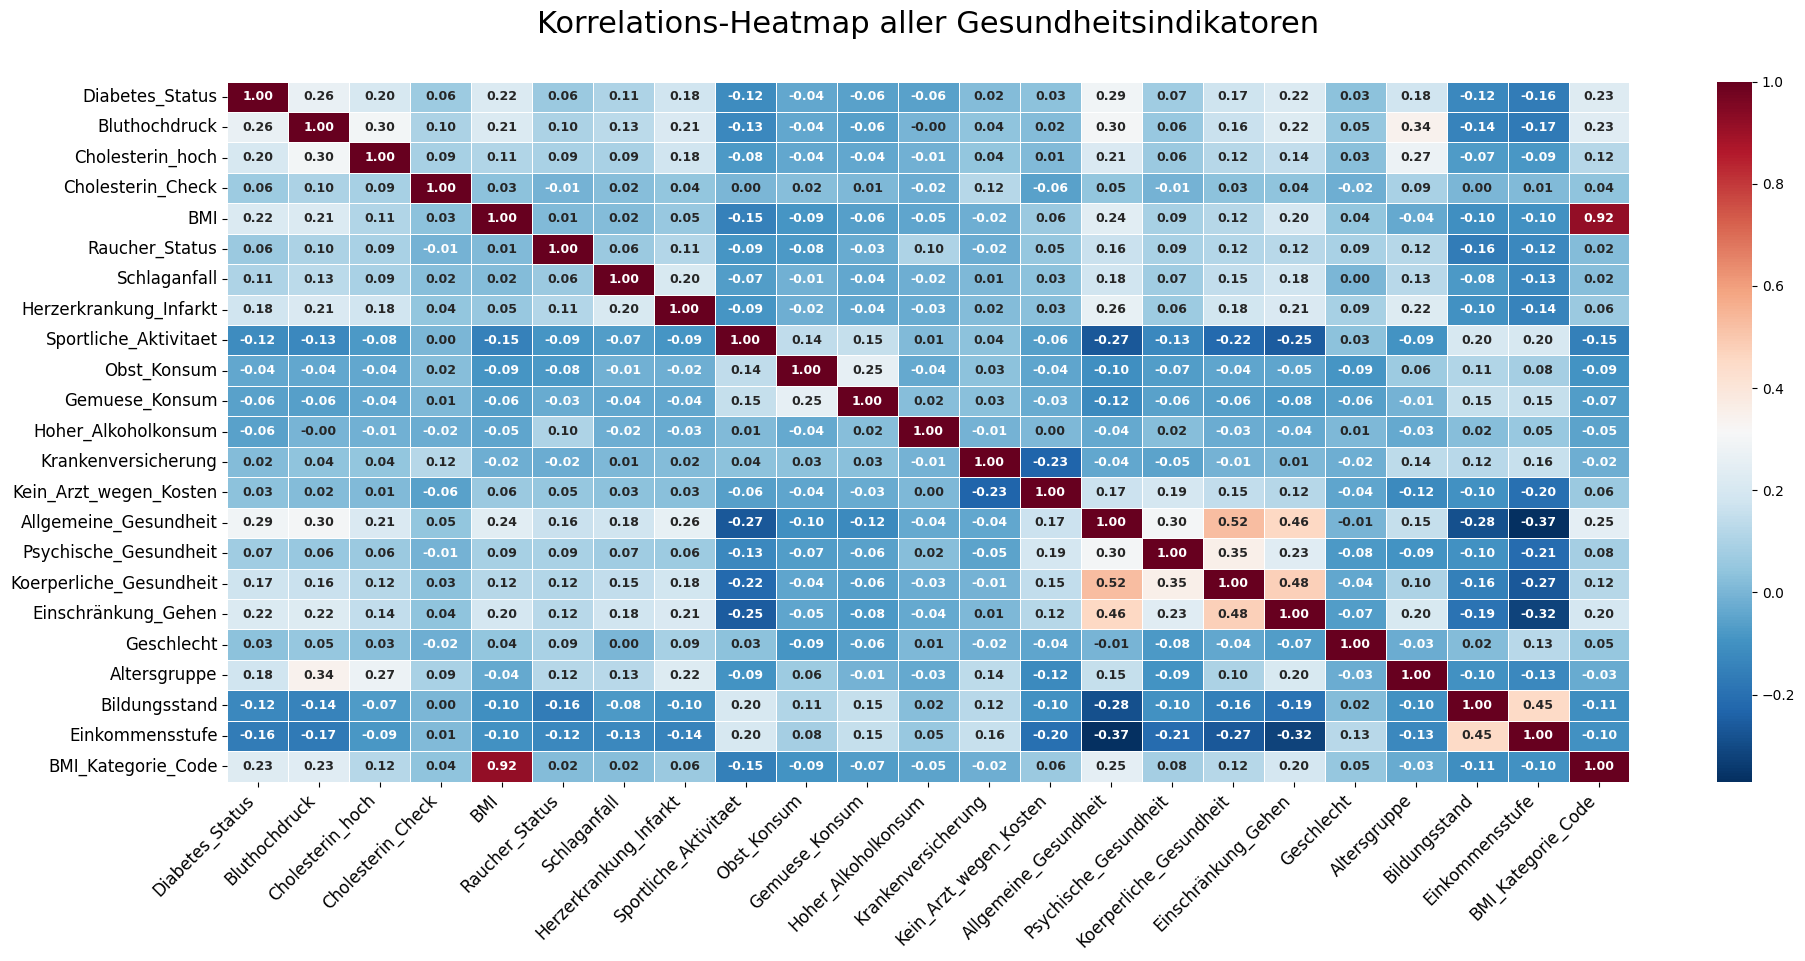

In [ ]:
# Korrelations-Heatmap

# numerischen Spalten auswählen
df_numerisch = df.select_dtypes(include=["number"])

# Korrelationsmatrix berechnen
corr_matrix = df_numerisch.corr()

# plotten
plt.figure(figsize=(20, 10))

# Heatmap in barrierefreier Palette 
sns.heatmap(
    corr_matrix,
    annot=True,             # Schreibt die Werte in die Kästchen
    cmap="RdBu_r",          # barrierefreie Palette 
    fmt=".2f",              # Rundet auf 2 Nachkommastellen
    linewidths=0.5,         # Feine Trennlinien zwischen den Quadraten
    annot_kws={
        "size": 9,
        "weight": "bold",   # Zahlen im Fettdruck
    },  
)

# für PowerPoint-Folie
plt.title("Korrelations-Heatmap aller Gesundheitsindikatoren", fontsize=22, pad=35)

# Beschriftungen drehen, damit Spaltennamen besser lesbar sind
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Ränder belassen absichern, damit nichts abgeschnitten wird
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.18)

# Optionale Speicherung in hoher Qualität für PowerPoint (Raute bei Bedarf entfernen)
# plt.savefig('korrelations_heatmap_deutsch.png', dpi=300, bbox_inches='tight')

plt.show()


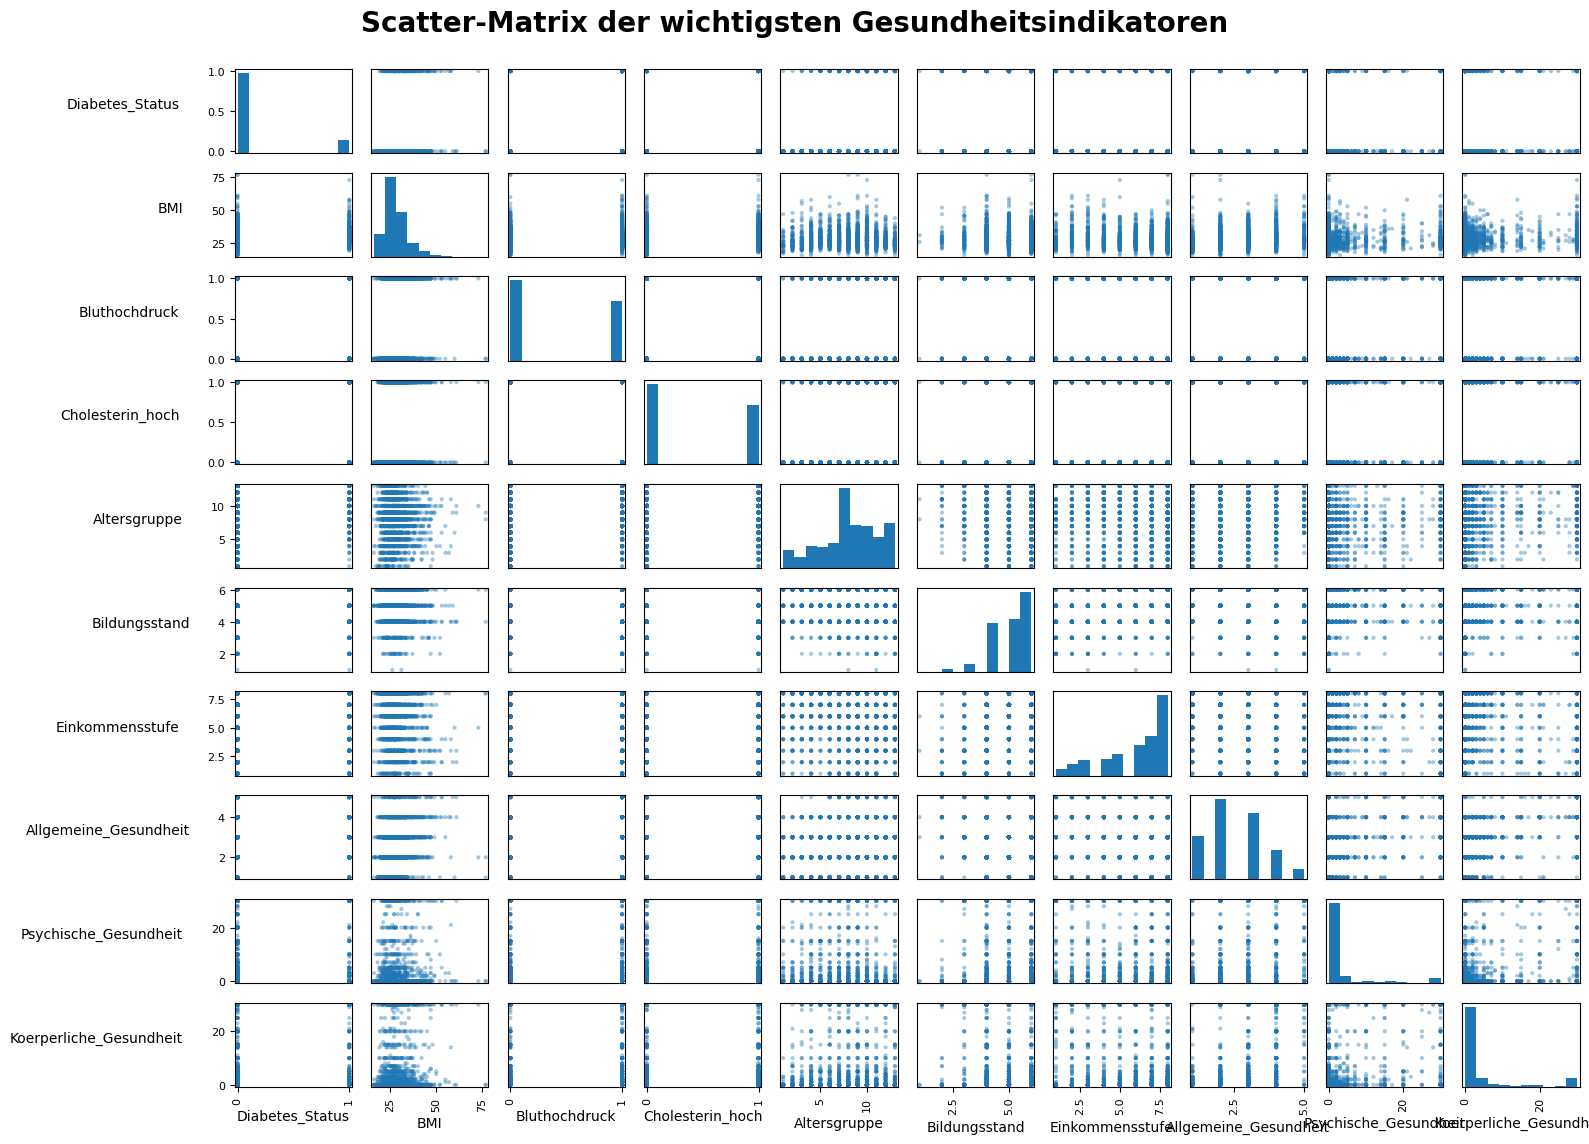

In [ ]:
# Scatter-Matrix

# Schlüsselvariablen für Überblick
kern_merkmale = [
    "Diabetes_Status",
    "BMI",
    "Bluthochdruck",
    "Cholesterin_hoch",
    "Altersgruppe",
    "Bildungsstand",
    "Einkommensstufe",
    "Allgemeine_Gesundheit",
    "Psychische_Gesundheit",
    "Koerperliche_Gesundheit"
]

# Stichprobe ziehen
df_auswahl = df[kern_merkmale].sample(n=2000, random_state=42)

# Scatter-Matrix plotten
axes = pd.plotting.scatter_matrix(
    df_auswahl,
    figsize=(16, 12),  # erhöhte Höhe
    alpha=0.4,
    diagonal="hist",
    grid=True,
)

# Alle Achsen durchlaufen und die Y-Beschriftungen
for ax in axes.flatten():
    # Y-Achsen-Texte komplett waagerecht drehen (0 Grad)
    ax.yaxis.get_label().set_rotation(0)
    # Den Text nach links schieben (ha='right'), damit er nicht ins Diagramm läuft
    ax.yaxis.get_label().set_horizontalalignment("right")
    # Zusätzlicher Abstand zur Achse (Pad), damit nichts überlappt
    ax.yaxis.labelpad = 20

# Titel hinzufügen
plt.suptitle(
    "Scatter-Matrix der wichtigsten Gesundheitsindikatoren",
    fontsize=20,
    y=0.95,
    fontweight="bold",
)

# Layout anpassen
plt.tight_layout()
plt.subplots_adjust(top=0.90, left=0.15)

plt.show()

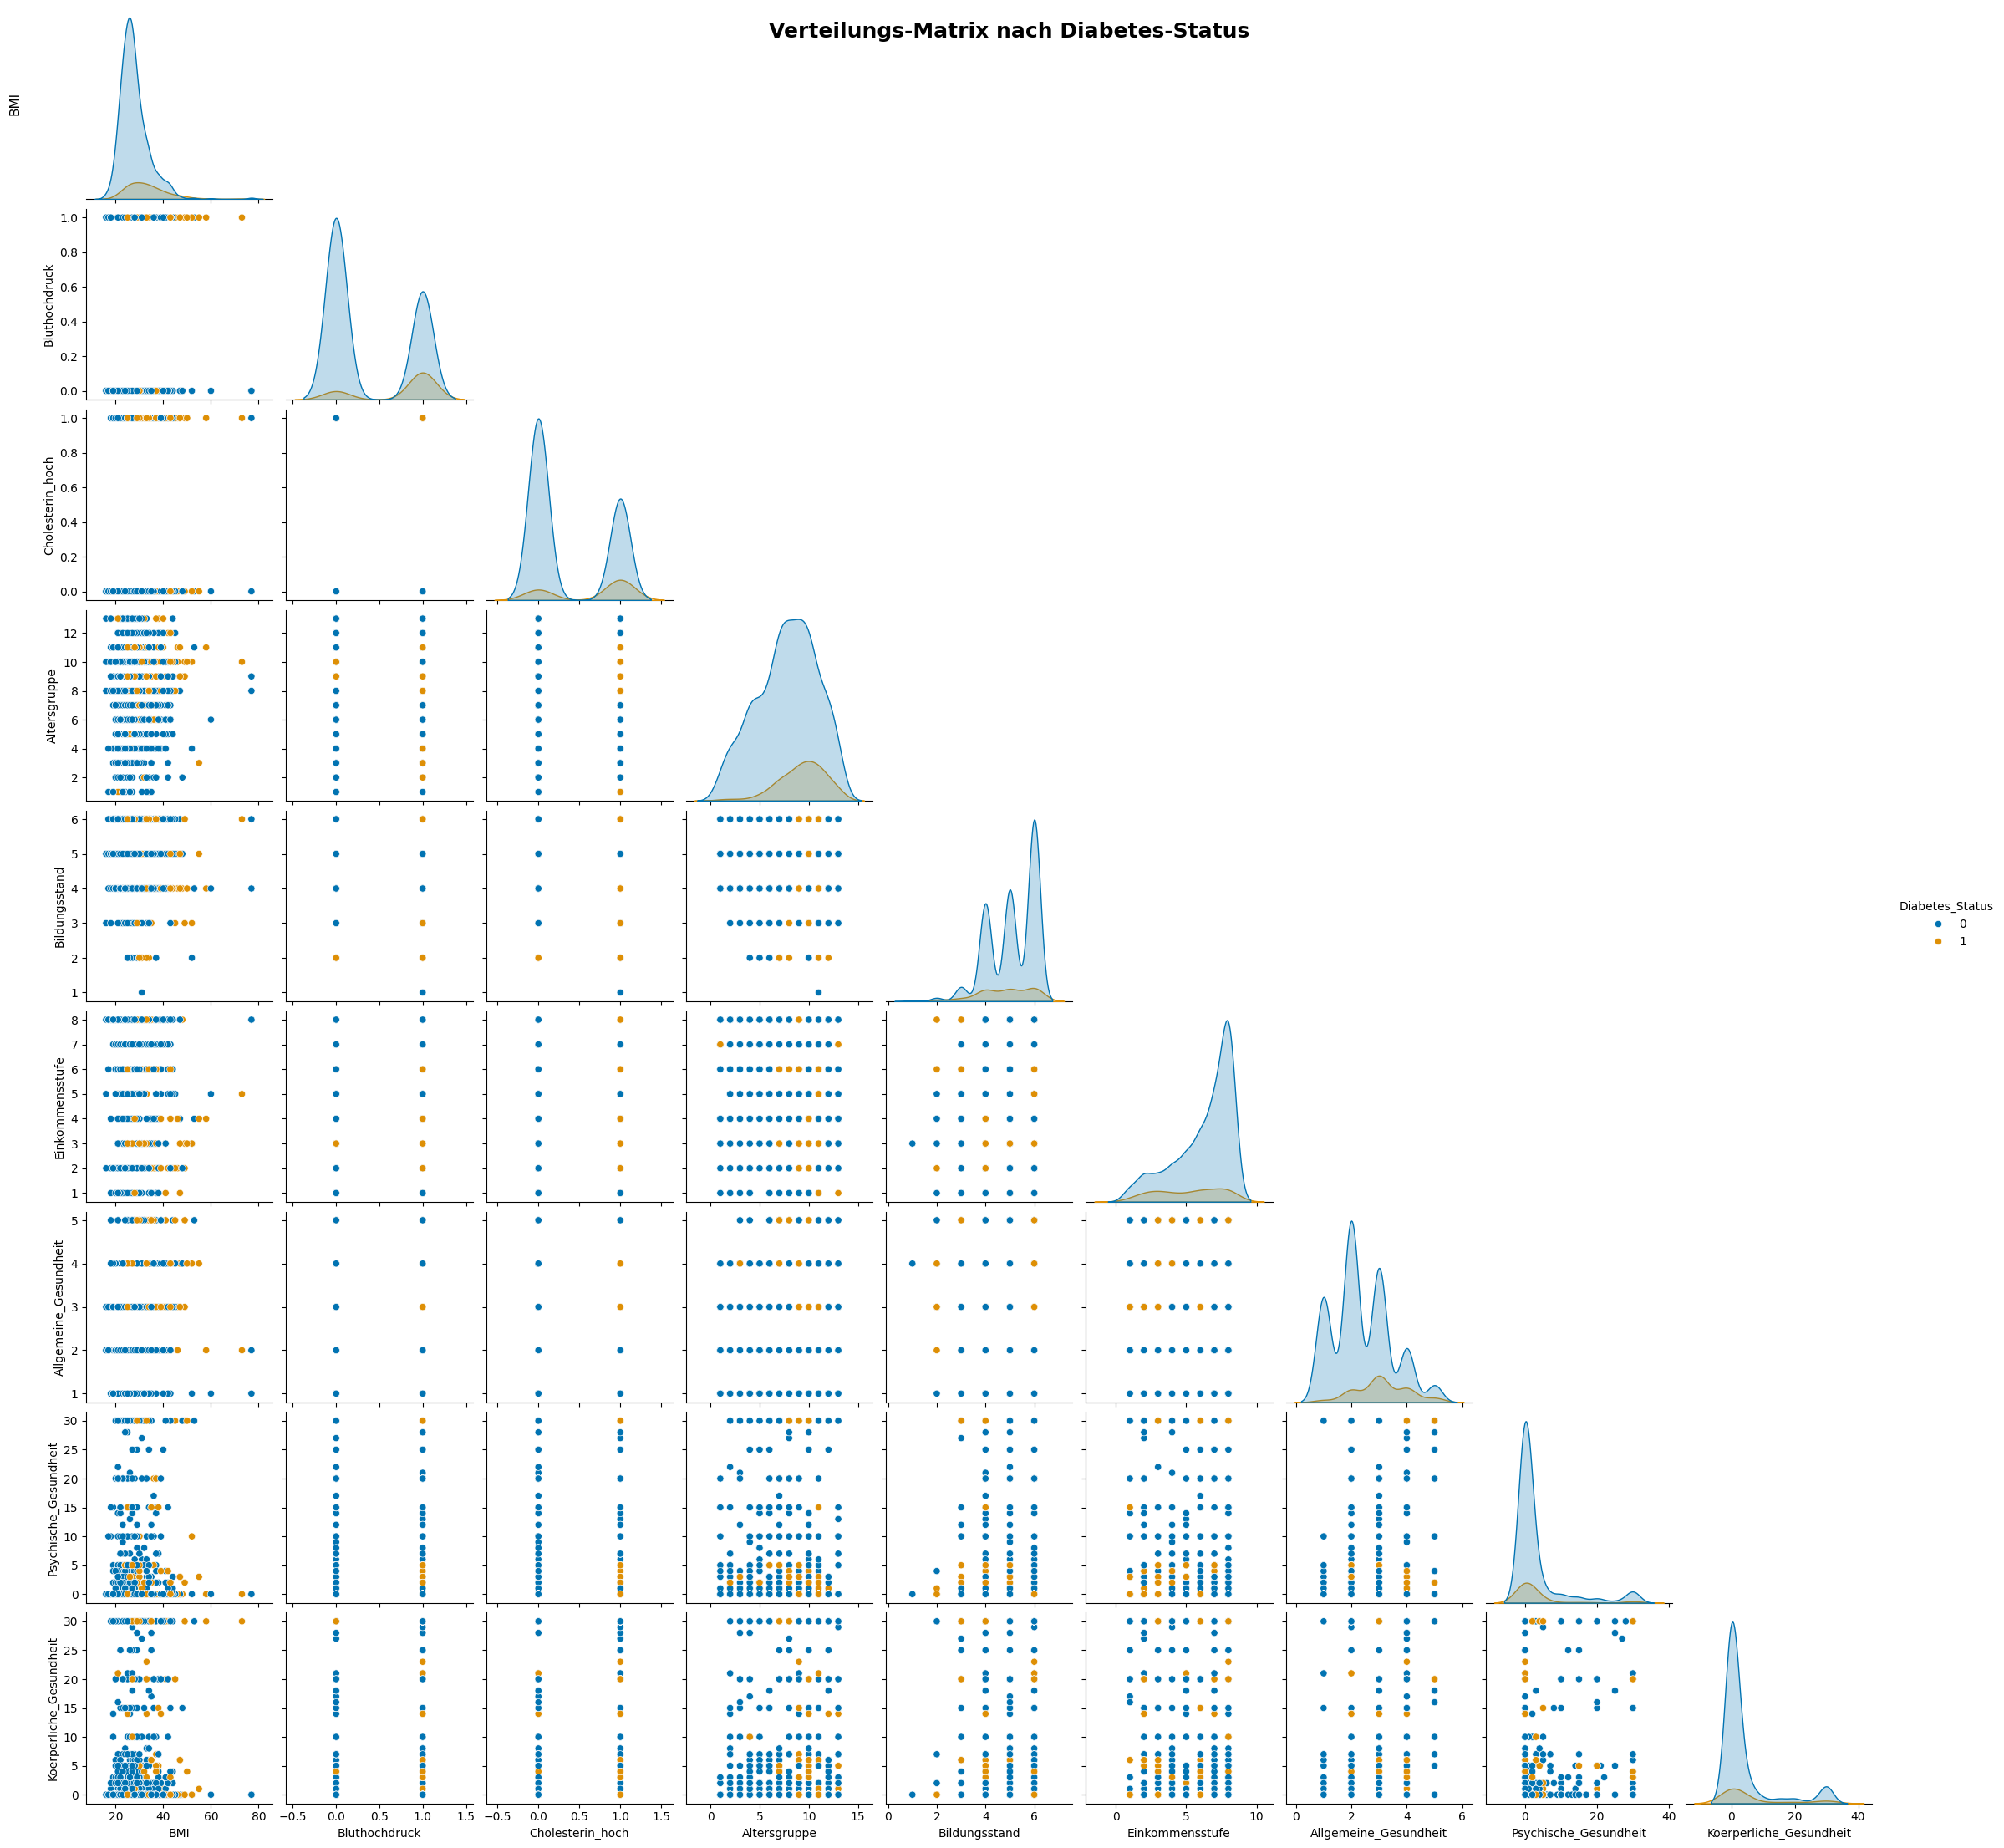

In [ ]:
# Seaborn Plot

# Stichprobe
df_sample = df.sample(n=1000, random_state=42)

# Schlüsselvariablen analog Scatter-Matrix
uebersicht_spalten = [
    "BMI",
    "Bluthochdruck",
    "Cholesterin_hoch",
    "Altersgruppe",
    "Bildungsstand",
    "Einkommensstufe",
    "Allgemeine_Gesundheit",
    "Psychische_Gesundheit",
    "Koerperliche_Gesundheit",
]

# Pairplot erzeugen (ganze Grafik unter g speichern; für nachträgliche Bearbeitung)
g = sns.pairplot(
    data=df_sample[uebersicht_spalten + ["Diabetes_Status"]],
    hue="Diabetes_Status",
    palette="colorblind",
    vars=uebersicht_spalten,
    corner=True,
    diag_kind="kde",
)

# BMI-Beschriftung link nks neben das erste Diagramm setzen. Seaborn gibt es nicht aus
g.axes.flatten()[0].text(
    -0.35,
    0.5,
    "BMI",
    transform=g.axes.flatten()[0].transAxes,
    rotation=90,
    verticalalignment="center",
    horizontalalignment="right",
    fontsize=11,
    color="black",
)

# Titel und Layout
plt.suptitle(
    "Verteilungs-Matrix nach Diabetes-Status",
    fontsize=18,
    y=0.98,
    fontweight="bold",
)

plt.show()


3) Datenanalyse und Visualsierungen

Daten sind strukturell in (X) und (y) aufgeteilt, wie man es für eine logistische Regression vorbereiten würde. 
Der Datensatz bleibt so organisiert, daß im Folgenden statistischen Häufigkeiten zwischen den Gruppen analysiert werden können.

Aus der Heatmap ergeben sich folgende Möglichkeiten zur Untersuchung: Wobei ich sehen möchte ob es einen Unterschied für Geschlechter gibt (den Aspekt werde ich evtl. wieder herausnehmen, wenn es zu aufwändig wird ---- Visualisierungen etc.)

1) wie erwartet der BMI
2) Bluthochdruck und Cholesterin 

3) Alter und Demografie
   Bildungsstand / Einkommenstufe

4) Lebensqualität und Folgeerscheinungen
   Frage könnte sein : Wie beeinflusst Diabetes die subjektive Lebensqualität und die mentale Gesundheit?
   Untersuchung der Variablen Allgemeine Gesundheit,  
                              Mentale Gesundheit und 
                              Körperliche Gesundheit. 
    Wieviel schlechter (viele Tage im Monat) fühlen sich Diabetiker im Vergleich zu Gesunden?





Datenanalyse und Visualisierung 

3.1 nach Geschlecht

3.2 nach BMI

3.1 nach Geschlecht

In [259]:
print(len(df['Geschlecht']))
print()
print(df['Geschlecht'].map({0.0: 'Frauen (0.0)', 1.0: 'Männer (1.0)'}).value_counts())

253680

Geschlecht
Frauen (0.0)    141974
Männer (1.0)    111706
Name: count, dtype: int64


In [ ]:
# Berechnungen

# Zusammensetzung gesamt und nach Geschlecht

# Prozentualen Anteil berechnen (Total = 100%) nach Geschlecht 
gesamt_aufteilung = (pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="all") * 100)
print(gesamt_aufteilung)
print()


Diabetes_Status          0         1
Geschlecht                          
0                48.708215  7.257569
1                37.358483  6.675733



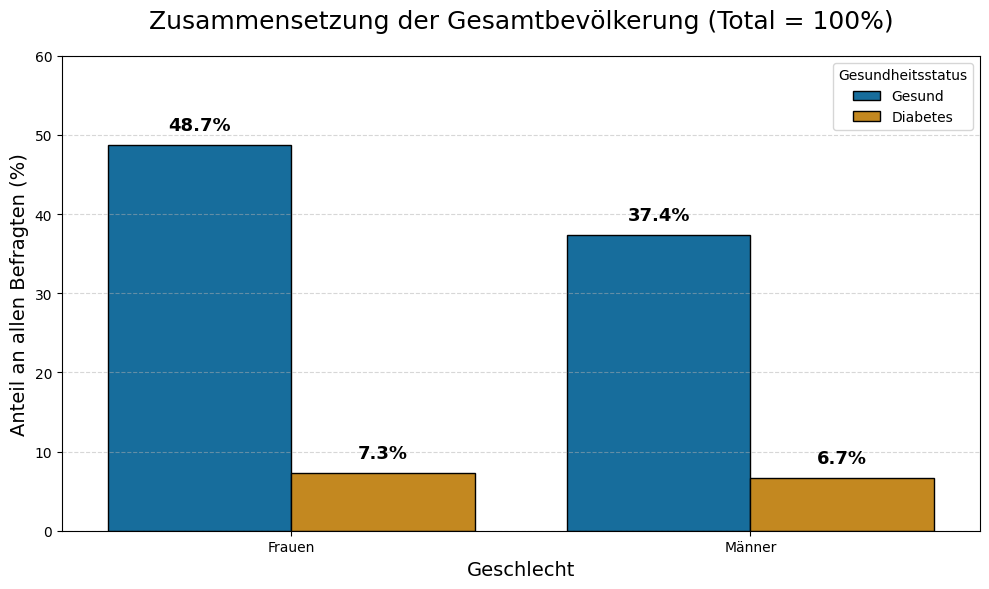

In [299]:
# Zusammensetzung gesamt und nach Geschlecht

# Prozentualen Anteil berechnen (Total = 100%) nach Geschlecht 
gesamt_aufteilung = (pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="all") * 100)

gesamt_df = gesamt_aufteilung.stack().reset_index()                                    # Seaborn gestapeltes Balkendiagramm
gesamt_df.columns = ["Geschlecht", "Diabetes_Status", "Prozent_an_Gesamtpopulation"]   # aus der Crosstab

# Beschriftungen
gesamt_df["Geschlecht"] = gesamt_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})
gesamt_df["Diabetes_Status"] = gesamt_df["Diabetes_Status"].map({0: "Gesund", 1: "Diabetes"})

# Seaborn Plot
plt.figure(figsize=(10, 6))

# Balkendiagramm 
ax = sns.barplot(
    data=gesamt_df,
    x="Geschlecht",
    y="Prozent_an_Gesamtpopulation",
    hue="Diabetes_Status",
    palette="colorblind",  # barrierefreies Farbschema
    edgecolor="black",
)

# Styling PowerPoint-Folie
plt.title("Zusammensetzung der Gesamtbevölkerung (Total = 100%)", fontsize=18, pad=20)
plt.xlabel("Geschlecht", fontsize=14)
plt.ylabel("Anteil an allen Befragten (%)", fontsize=14)
plt.ylim(0, 60)                                           # Platz nach oben für die Text-Labels
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Legende
plt.legend(title="Gesundheitsstatus", loc="upper right")

# Schleife, um Prozentzahlen über die Balken zu schreiben
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",       # Formatiert als Fließkommazahl mit Prozentzeichen
        label_type="edge",
        padding=8,          # Abstand nach oben
        color="black",
        fontweight="bold",
        fontsize=13,
    )

plt.tight_layout()
plt.show()


3.2 nach BMI

In [300]:
print(df[["BMI", "BMI_Kategorie_Text"]].value_counts().sort_index())

df[df["BMI"] >= 40]["BMI"].value_counts()

BMI  BMI_Kategorie_Text           
12   Untergewicht (< 18.5)              6
13   Untergewicht (< 18.5)             21
14   Untergewicht (< 18.5)             41
15   Untergewicht (< 18.5)            132
16   Untergewicht (< 18.5)            348
                                     ... 
91   Adipositas Grad III (>= 40.0)      1
92   Adipositas Grad III (>= 40.0)     32
95   Adipositas Grad III (>= 40.0)     12
96   Adipositas Grad III (>= 40.0)      1
98   Adipositas Grad III (>= 40.0)      7
Name: count, Length: 84, dtype: int64


BMI
40    2258
41    1659
42    1639
43    1500
44    1043
45     819
46     750
47     622
48     484
49     416
50     372
51     253
53     237
52     215
55     169
54     113
56     109
57      86
58      71
79      66
60      63
87      61
77      55
59      54
75      52
81      49
71      49
73      47
84      44
62      43
82      37
61      35
63      34
92      32
89      28
64      24
65      19
74      16
67      15
70      15
68      14
72      14
66      13
95      12
69       9
98       7
76       3
88       2
83       2
80       2
85       1
96       1
91       1
86       1
90       1
78       1
Name: count, dtype: int64

In [ ]:
# bei Bedarf die # entfernen

#print(df["BMI_Kategorie_Code"].head())   # zeigt BMI_Kategorie_Codes an
                

Signature: bmi_kategorie_code(bmi)
Docstring: <no docstring>
File:      c:\users\keron\appdata\local\temp\ipykernel_2584\77083497.py
Type:      function

In [ ]:
# Absolute Häufigkeiten berechnen (nutzt die Definition -> def bmi_kategorie_code)


bmi_counts = df["BMI_Kategorie_Text"].value_counts().reindex(reihenfolge_who)

print("--- 1. Absolute Anzahl Personen im Datensatz ---")
print()
for kat in reihenfolge_who:
    anzahl = bmi_counts[kat]                            # Anzahl Personen in der Gewichtsklasse
    print(f"{kat:<32} | Anzahl Personen: {anzahl:,}")   # linksbündig 32 Zeichen reservieren 
print()

# Reale Diabetes-Rate (in %) innerhalb der Gruppen berechnen
bmi_rates_who = df.groupby("BMI_Kategorie_Text")["Diabetes_Status"].mean() * 100

print("--- 2. Reale Diabetes-Rate innerhalb der Gruppen ---")
print()
for kat in reihenfolge_who:
    rate = bmi_rates_who[kat]
    print(f"{kat:<32} | Diabetes-Rate: {rate:.1f}%")

--- 1. Absolute Anzahl Personen im Datensatz ---

Untergewicht (< 18.5)            | Anzahl Personen: 3,127
Normalgewicht (18.5 - 24.9)      | Anzahl Personen: 68,953
Übergewicht (25.0 - 29.9)        | Anzahl Personen: 93,749
Adipositas Grad I (30.0 - 34.9)  | Anzahl Personen: 53,451
Adipositas Grad II (35.0 - 39.9) | Anzahl Personen: 20,663
Adipositas Grad III (>= 40.0)    | Anzahl Personen: 13,737

--- 2. Reale Diabetes-Rate innerhalb der Gruppen ---

Untergewicht (< 18.5)            | Diabetes-Rate: 5.4%
Normalgewicht (18.5 - 24.9)      | Diabetes-Rate: 5.7%
Übergewicht (25.0 - 29.9)        | Diabetes-Rate: 11.4%
Adipositas Grad I (30.0 - 34.9)  | Diabetes-Rate: 19.2%
Adipositas Grad II (35.0 - 39.9) | Diabetes-Rate: 27.4%
Adipositas Grad III (>= 40.0)    | Diabetes-Rate: 33.5%


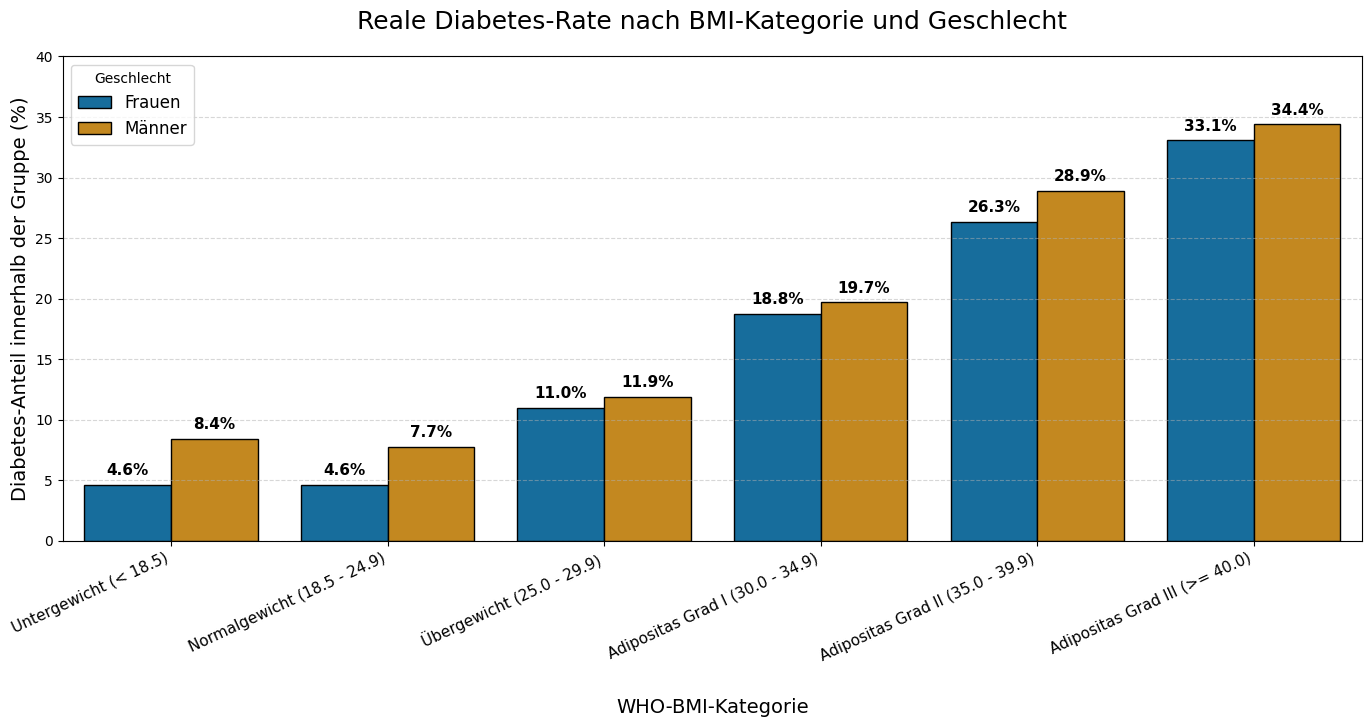

In [348]:

# Daten aggregieren: Berechnet die Diabetes-Rate (%) nach BMI-Kategorie und Geschlecht
# gruppieren nach beiden Spalten und berechnen den Mittelwert der Zielvariablen Diabetes_Status
bmi_geschlecht_rates = (
    df.groupby(["BMI_Kategorie_Text", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()       

# numerischen Geschlechter-Codes (0 und 1) für die Grafik übersetzen
bmi_geschlecht_rates["Geschlecht"] = bmi_geschlecht_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# pLOT
plt.figure(figsize=(14, 7))

# Gruppiertes Balkendiagramm erstellen
# 'order=reihenfolge_who' sorgt dafür, dass die BMI-Klassen logisch sortiert auf der Achse liegen.
ax = sns.barplot(
    data=bmi_geschlecht_rates,
    x="BMI_Kategorie_Text",
    y="Diabetes_Status",
    hue="Geschlecht",
    order=reihenfolge_who,  # Nutzt definierte Reihenfolge
    palette="colorblind",   # Barrierefreies Farbschema
    edgecolor="black",
)

# Styling für PowerPoint-Folie
plt.title("Reale Diabetes-Rate nach BMI-Kategorie und Geschlecht", fontsize=18, pad=20)
plt.xlabel("WHO-BMI-Kategorie", fontsize=14, labelpad=25)
plt.ylabel("Diabetes-Anteil innerhalb der Gruppe (%)", fontsize=14)
plt.ylim(0, 40)                                        # Genug Platz für die Text-Labels
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Legende positionieren
plt.legend(title="Geschlecht", loc="upper left", fontsize=12)

# Beschriftung X-Achse ankippen
plt.xticks(rotation=25, ha="right", fontsize=11)

# Prozentzahlen über Balken schreiben
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=5,
        color="black",
        fontweight="bold",
        fontsize=11,
    )

# Layout optimieren und anzeigen
plt.tight_layout()
plt.subplots_adjust(bottom=0.22) 


Achtung ab hier weiter arbeiten und überprüfen....

In [362]:
# Berechnungen

#Risikopunkt nach BMI

# Relevanten BMI-Bereich filtern
df_kurve_gefiltert = df[(df["BMI"] >= 18) & (df["BMI"] <= 50)]
print(df_kurve_gefiltert)
print()

# Die reale Diabetes-Rate pro exaktem BMI-Wert berechnen (in %)
bmi_trend_gefiltert = df_kurve_gefiltert.groupby("BMI")["Diabetes_Status"].mean() * 100
print(bmi_trend_gefiltert)
print()

        Diabetes_Status  Bluthochdruck  Cholesterin_hoch  Cholesterin_Check  \
0                     0              1                 1                  1   
1                     0              0                 0                  0   
2                     0              1                 1                  1   
3                     0              1                 0                  1   
4                     0              1                 1                  1   
...                 ...            ...               ...                ...   
253675                0              1                 1                  1   
253676                1              1                 1                  1   
253677                0              0                 0                  1   
253678                0              1                 0                  1   
253679                1              1                 1                  1   

        BMI  Raucher_Status  Schlaganfall  Herzerkr

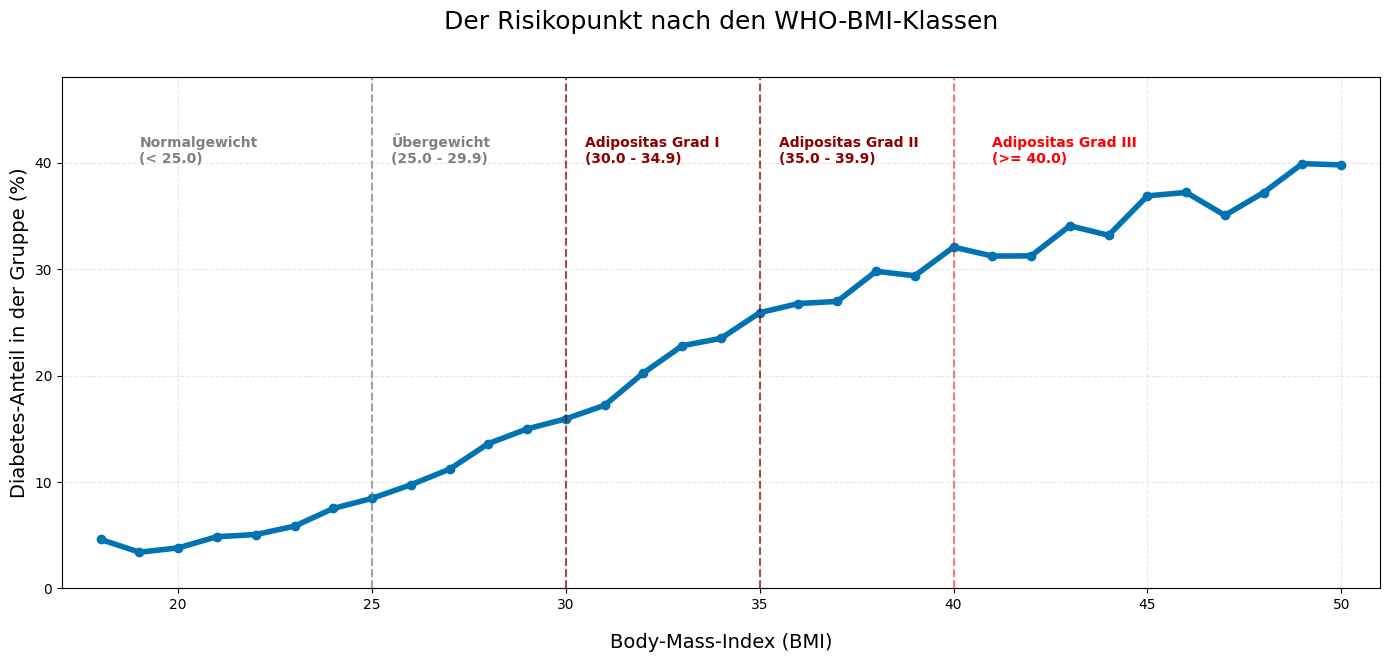

In [354]:
# Der Risikopunkt nach den WHO-BMI-Klassen

# relevanten BMI-Bereich filtern, um extremes Rauschen am Ende zu verhindern
df_kurve = df[(df['BMI'] >= 18) & (df['BMI'] <= 50)]

# reale Diabetes-Rate pro BMI-Wert berechnen in %
bmi_trend = df_kurve.groupby("BMI")["Diabetes_Status"].mean() * 100

# Plot erstellen
plt.figure(figsize=(14, 7))

# Blau aus Colorblind-Palette für Kurve
colorblind_blue = sns.color_palette("colorblind")[0]
plt.plot(
    bmi_trend.index,
    bmi_trend.values,
    color=colorblind_blue,
    linewidth=4,
    marker="o",
    markersize=6,
)

# Orientierungslinien nach den detaillierten WHO-Klassen
plt.axvline(x=25, color="gray", linestyle="--", alpha=0.7)     # Schwelle zu Übergewicht
plt.axvline(x=30, color="darkred", linestyle="--", alpha=0.7)  # Schwelle zu Adipositas Grad I
plt.axvline(x=35, color="darkred", linestyle="--", alpha=0.7)  # Schwelle zu Adipositas Grad II
plt.axvline(x=40, color="red", linestyle="--", alpha=0.5)      # Schwelle zu Adipositas Grad III

# Text über den Abschnitten
plt.text(
    19.0,
    40,
    "Normalgewicht\n(< 25.0)",
    color="gray",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    25.5,
    40,
    "Übergewicht\n(25.0 - 29.9)",
    color="gray",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    30.5,
    40,
    "Adipositas Grad I\n(30.0 - 34.9)",
    color="darkred",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    35.5,
    40,
    "Adipositas Grad II\n(35.0 - 39.9)",
    color="darkred",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    41.0,
    40,
    "Adipositas Grad III\n(>= 40.0)",
    color="red",
    fontsize=10,
    fontweight="bold",
)

# Beschriftungen
# Titel
plt.title(
    "Der Risikopunkt nach den WHO-BMI-Klassen",
    fontsize=18,
    pad=35,
)

#Label
plt.xlabel("Body-Mass-Index (BMI)", fontsize=14, labelpad=15)
plt.ylabel("Diabetes-Anteil in der Gruppe (%)", fontsize=14)

plt.xlim(17, 51)
plt.ylim(0, 48)         # Leicht erhöht, damit die oberen Texte nicht an den Rand stoßen
plt.grid(True, linestyle="--", alpha=0.3)

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.12)

# Grafik direkt als Bild speichern:
# plt.savefig('diabetes_kurve_who_details.png', dpi=300, bbox_inches='tight')

plt.show()


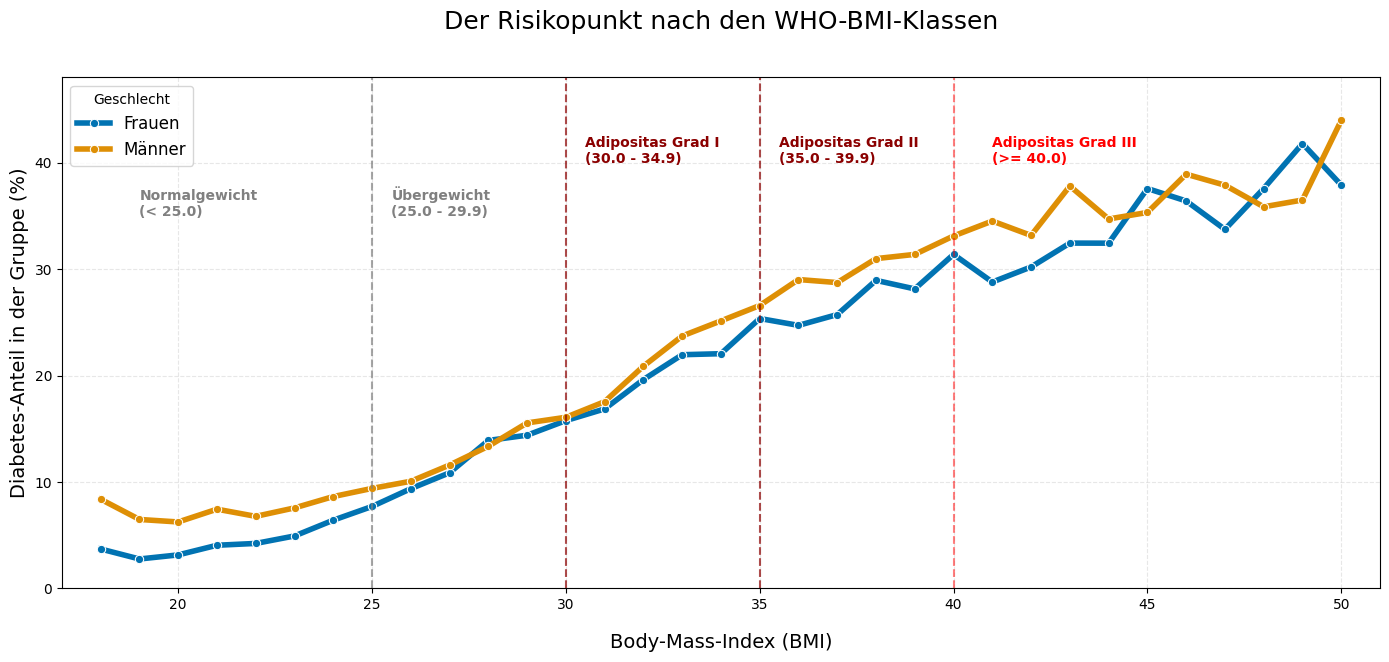

In [359]:
# "Der Risikopunkt nach den WHO-BMI-Klassen" Männer und Frauen

# relevanten BMI-Bereich filtern
df_kurve = df[(df["BMI"] >= 18) & (df["BMI"] <= 50)]

# reale Diabetes-Rate pro exaktem BMI-Wert getrennt nach Geschlecht berechnen in % 
trend_geschlecht = (df_kurve.groupby(["BMI", "Geschlecht"])["Diabetes_Status"].mean().reset_index())  # Übersetzung aus Rahmen (BMI, Geschlecht...) in Spalten einer Tabelle
trend_geschlecht["Diabetes_Status"] *= 100                                                            # In Prozent umrechnen

# Spaltenwerte für die Legende
trend_geschlecht["Geschlecht"] = trend_geschlecht["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Plot
plt.figure(figsize=(14, 7))

# Liniendiagramm mit Colorblind-Schema (Blau und Orange)
ax = sns.lineplot(
    data=trend_geschlecht,
    x="BMI",
    y="Diabetes_Status",
    hue="Geschlecht",
    palette="colorblind",
    linewidth=4,
    marker="o",
    markersize=6,
)

# Orientierungslinien nach detaillierten WHO-Klassen
plt.axvline(x=25, color="gray", linestyle="--", alpha=0.7)     # Schwelle zu Übergewicht
plt.axvline(x=30, color="darkred", linestyle="--", alpha=0.7)  # Schwelle zu Adipositas Grad I
plt.axvline(x=35, color="darkred", linestyle="--", alpha=0.7)  # Schwelle zu Adipositas Grad II
plt.axvline(x=40, color="red", linestyle="--", alpha=0.5)      # Schwelle zu Adipositas Grad III

# Text-Anmerkungen über den Abschnitten 
plt.text(
    19.0,
    35,
    "Normalgewicht\n(< 25.0)",
    color="gray",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    25.5,
    35,
    "Übergewicht\n(25.0 - 29.9)",
    color="gray",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    30.5,
    40,
    "Adipositas Grad I\n(30.0 - 34.9)",
    color="darkred",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    35.5,
    40,
    "Adipositas Grad II\n(35.0 - 39.9)",
    color="darkred",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    41.0,
    40,
    "Adipositas Grad III\n(>= 40.0)",
    color="red",
    fontsize=10,
    fontweight="bold",
)

# Beschriftungen

# Titel
plt.title(
    "Der Risikopunkt nach den WHO-BMI-Klassen",
    fontsize=18,
    pad=35,
)

# Label
plt.xlabel("Body-Mass-Index (BMI)", fontsize=14, labelpad=15)
plt.ylabel("Diabetes-Anteil in der Gruppe (%)", fontsize=14)

plt.xlim(17, 51)
plt.ylim(0, 48)                           # Leicht erhöht, damit die oberen Texte nicht an den Rand stoßen
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Geschlecht", loc="upper left", fontsize=12)

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.12)

# Grafik direkt als Bild speichern:
# plt.savefig('diabetes_kurve_who_details.png', dpi=300, bbox_inches='tight')

plt.show()




Die Gesamtgrafik ist zu unübersichtlich  -- die werfe ich raus





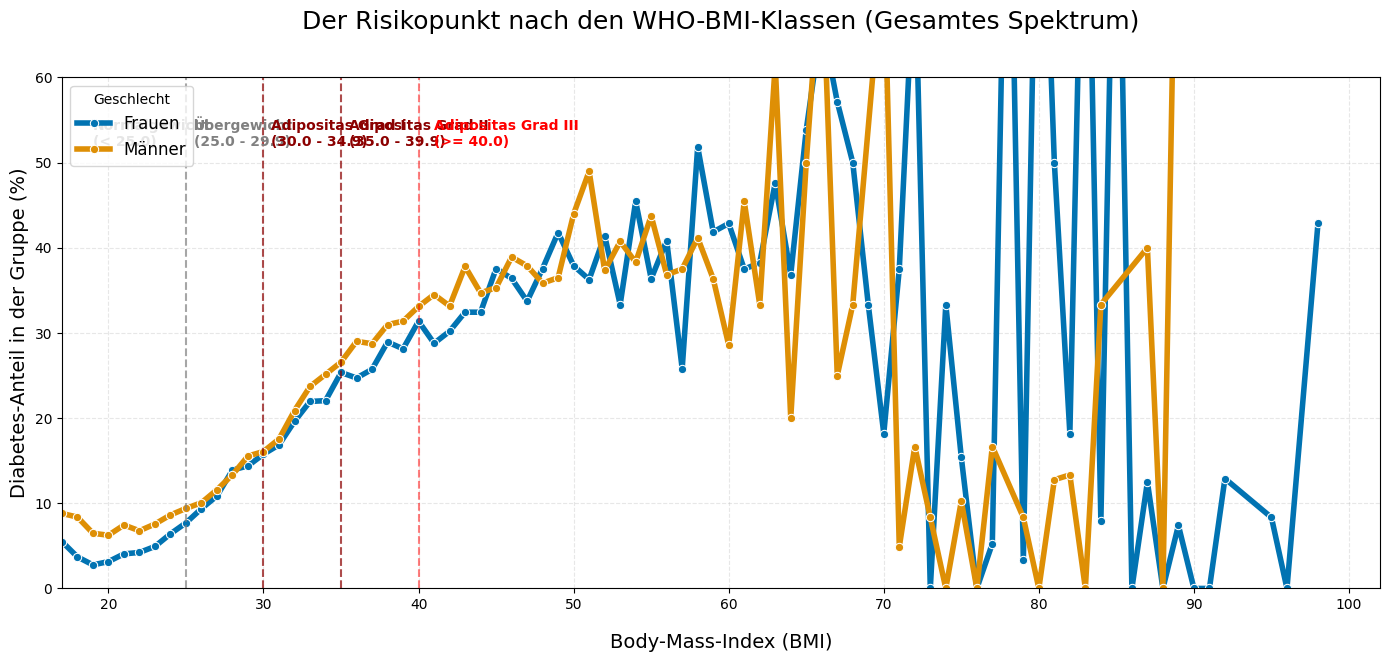

In [ ]:
# kompletter BMI-Bereich 

# BMI-Bereich 
df_kurve = df.copy()

# Diabetes-Rate pro 
trend_geschlecht = (
    df_kurve.groupby(["BMI", "Geschlecht"])["Diabetes_Status"]
    .mean()
    .reset_index()
)
trend_geschlecht["Diabetes_Status"] *= 100  # In Prozent umrechnen

# Spaltenwerte für die Legende übersetzen
trend_geschlecht["Geschlecht"] = trend_geschlecht["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Plot erstellen
plt.figure(figsize=(14, 7))

# Liniendiagramm mit Blau und Orange
ax = sns.lineplot(
    data=trend_geschlecht,
    x="BMI",
    y="Diabetes_Status",
    hue="Geschlecht",
    palette="colorblind",
    linewidth=4,
    marker="o",
    markersize=6,
)

# Orientierungslinien nach den detaillierten WHO-Klassen einzeichnen
plt.axvline(x=25, color="gray", linestyle="--", alpha=0.7)     # Schwelle zu Übergewicht
plt.axvline(x=30, color="darkred", linestyle="--", alpha=0.7)  # Schwelle zu Adipositas Grad I
plt.axvline(x=35, color="darkred", linestyle="--", alpha=0.7)  # Schwelle zu Adipositas Grad II
plt.axvline(x=40, color="red", linestyle="--", alpha=0.5)      # Schwelle zu Adipositas Grad III

# Text-Anmerkungen über den Abschnitten 
plt.text(
    19.0,
    52,
    "Normalgewicht\n(< 25.0)",
    color="gray",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    25.5,
    52,
    "Übergewicht\n(25.0 - 29.9)",
    color="gray",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    30.5,
    52,
    "Adipositas Grad I\n(30.0 - 34.9)",
    color="darkred",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    35.5,
    52,
    "Adipositas Grad II\n(35.0 - 39.9)",
    color="darkred",
    fontsize=10,
    fontweight="bold",
)
plt.text(
    41.0,
    52,
    "Adipositas Grad III\n(>= 40.0)",
    color="red",
    fontsize=10,
    fontweight="bold",
)

# Beschriftungen
# Titel
plt.title(
    "Der Risikopunkt nach den WHO-BMI-Klassen (Gesamtes Spektrum)",
    fontsize=18,
    pad=35,
)

# Label
plt.xlabel("Body-Mass-Index (BMI)", fontsize=14, labelpad=15)
plt.ylabel("Diabetes-Anteil in der Gruppe (%)", fontsize=14)

# Grenzen erweitert, um alle Werte bis zum Maximum abzubilden
plt.xlim(17, 102)
plt.ylim(0, 60)  # Auf 60 erhöht
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Geschlecht", loc="upper left", fontsize=12)

# Layout
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.12)

# Grafik direkt als Bild speichern:
# plt.savefig('diabetes_kurve_geschlecht_all.png', dpi=300, bbox_inches='tight')

plt.show()


Den Abschnitt bearbeiten

weiter mit Cholesterin udn Bluthochdruck...

danach die anderen Risikofaktoren....
einfacher sie in einem zu berechnen als Überblick
Details dann später

In [ ]:
# Berechnungen 
# für alle Faktoren (Übersicht) 

# Diabetes Rate nach Risikofaktoren 

# Allgemeine Diabetes-Rate des gesamten Datensatzes als Baseline berechnen
baseline_rate = df["Diabetes_Status"].mean() * 100

# Die Diabetes-Raten für die gewählten Risikogruppen berechnen (in %)
rate_bluthochdruck = df[df["Bluthochdruck"] == 1]["Diabetes_Status"].mean() * 100           # Wert = 1 für hohes Risiko
rate_bmi = df[df["BMI"] >= 30]["Diabetes_Status"].mean() * 100                              # BMI 30 = medizinischer Trennwert
rate_cholesterin = df[df["Cholesterin_hoch"] == 1]["Diabetes_Status"].mean() * 100          # Wert = 1 für hohes Risiko
rate_alter = df[df["Altersgruppe"] >= 9]["Diabetes_Status"].mean() * 100                    # >= 9 entspricht ca.60 Jahr
rate_allg_ges = df[df["Allgemeine_Gesundheit"] >= 4]["Diabetes_Status"].mean() * 100        # >=4 d.h. >14 Tage krank im Monat
rate_psych_ges = df[df["Psychische_Gesundheit"] > 14]["Diabetes_Status"].mean() * 100       # >4 d.h. >14 Tage krank im Monat
rate_koerp_ges = df[df["Koerperliche_Gesundheit"] > 14]["Diabetes_Status"].mean() * 100     # Wert = 1 für hohes Risiko
rate_bildung = df[df["Bildungsstand"] == 1]["Diabetes_Status"].mean() * 100                 # Wert = 1 für hohes Risiko
rate_einkommen = df[df["Einkommensstufe"] == 1]["Diabetes_Status"].mean() * 100             # Wert = 1 für hohes Risiko 

# Daten für Ausgabe und spätere Grafik in übersichtliche Tabellen-Struktur bringen
faktoren_data_10 = pd.DataFrame(
    {
        "Risikofaktor": [
            "Bluthochdruck",
            "BMI",
            "Cholesterin_hoch",
            "Altersgruppe",
            "Allgemeine_Gesundheit",
            "Psychische_Gesundheit",
            "Koerperliche_Gesundheit",
            "Bildungsstand",
            "Einkommensstufe",
        ],
        "Diabetes_Rate": [
            rate_bluthochdruck,
            rate_bmi,
            rate_cholesterin,
            rate_alter,
            rate_allg_ges,
            rate_psych_ges,
            rate_koerp_ges,
            rate_bildung,
            rate_einkommen,
        ],
    }
)

# Nach der Höhe der Diabetes-Rate sortieren 
faktoren_data_10 = faktoren_data_10.sort_values(by="Diabetes_Rate", ascending=False)  # absteigende Rangliste

# Print Ergebnisse
print(f"Diabetes-Raten nach den 10 Fokus-Risikofaktoren (Baseline: {baseline_rate:.1f}%)")
print()  # Abstandszeile

for index, row in faktoren_data_10.iterrows():
    print(f"{row['Risikofaktor']}: {row['Diabetes_Rate']:.1f}%")     # eine Stelle nach dem Komma


Diabetes-Raten nach den 10 Fokus-Risikofaktoren (Baseline: 13.9%)

Allgemeine_Gesundheit: 32.9%
Koerperliche_Gesundheit: 28.6%
Bildungsstand: 27.0%
Bluthochdruck: 24.4%
Einkommensstufe: 24.3%
BMI: 23.4%
Cholesterin_hoch: 22.0%
Psychische_Gesundheit: 21.2%
Altersgruppe: 19.7%


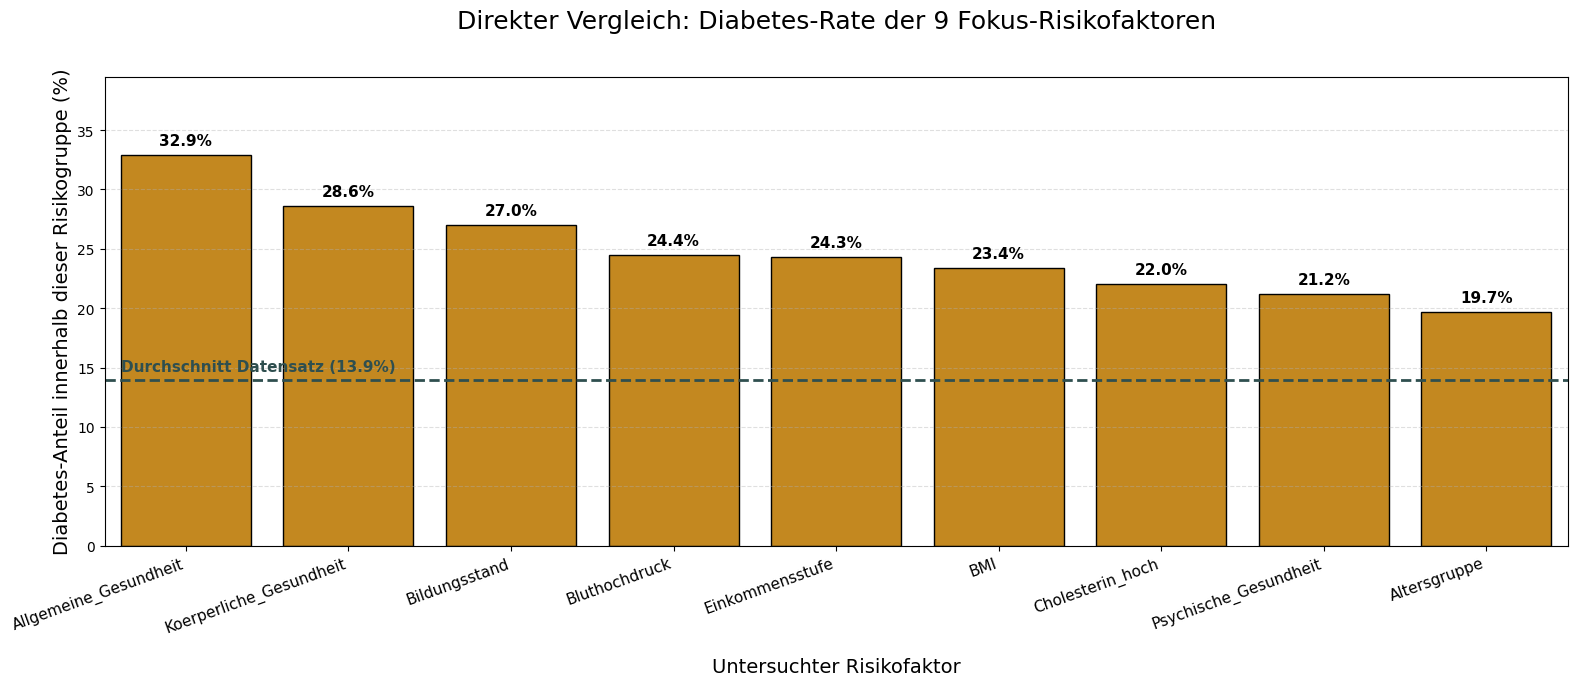

In [ ]:
# Grafik "Direkter Vergleich: Diabetes-Rate der 9 Fokus-Risikofaktoren",
# Übersicht 

# Plot-Größe festlegen
plt.figure(figsize=(16, 7))

# Orange aus der colorblind Palette
colorblind_orange = sns.color_palette("colorblind")[1]

# Balkendiagramm erstellen 
ax = sns.barplot(
    data=faktoren_data_10,
    x="Risikofaktor",
    y="Diabetes_Rate",
    color=colorblind_orange,  
    edgecolor="black",
)

# Durchschnitt aller Befragten als graue Linie einzeichnen
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--", linewidth=2)
plt.text(
    -0.4,
    baseline_rate + 0.8,
    f"Durchschnitt Datensatz ({baseline_rate:.1f}%)",
    color="darkslategray", #"black","gray"
    fontsize=11,
    fontweight="bold",
)

# Styling für PowerPoint (Erweiterte Ränder, damit nichts abschneidet)
plt.title(
    "Direkter Vergleich: Diabetes-Rate der 9 Fokus-Risikofaktoren",
    fontsize=18,
    pad=35,
)
plt.xlabel("Untersuchter Risikofaktor", fontsize=14, labelpad=15)
plt.ylabel("Diabetes-Anteil innerhalb dieser Risikogruppe (%)", fontsize=14)

# X-Achsen Beschriftung leicht ankippen
plt.xticks(rotation=20, ha="right", fontsize=11)

# Y-Limit erweitern, damit die Zahlen über den Balken Platz haben
plt.ylim(0, faktoren_data_10["Diabetes_Rate"].max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Prozentzahlen automatisch über die Balken schreiben
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=5,
        color="black",
        fontweight="bold",
        fontsize=11,
    )

# Rand-Korrektur für den PowerPoint-Export
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.18)

plt.show()



nach Alterstufen und Männer und Frauen unterschieden

In [408]:
# Berechnung Altersgruppe und Geschlecht

# Diabetes-Rate (%) nach Altersgruppe und Geschlecht berechnen
alter_geschlecht_rates = (df.groupby(["Altersgruppe", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()

# Die numerischen Geschlechter-Codes 0/1 in Frauen/Männer übersetzen
alter_geschlecht_rates["Geschlecht_Text"] = alter_geschlecht_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Ergebnis ausdrucken 
print("Diabetes-Raten nach Altersgruppen und Geschlecht")
print()  # Abstandszeile
for index, row in alter_geschlecht_rates.iterrows():
    alt_stufe = int(row["Altersgruppe"])
    geschl = row["Geschlecht_Text"]
    rate_wert = row["Diabetes_Status"]
    # Ausrichtung Spalten im Printout
    print(f"Altersstufe {alt_stufe:<2} | {geschl:<7} | Diabetes-Rate: {rate_wert:.1f}%")  #jeweils linksbündig; Anzahl der reservierten Buchstaben für das Wort



Diabetes-Raten nach Altersgruppen und Geschlecht

Altersstufe 1  | Frauen  | Diabetes-Rate: 1.6%
Altersstufe 1  | Männer  | Diabetes-Rate: 1.1%
Altersstufe 2  | Frauen  | Diabetes-Rate: 2.2%
Altersstufe 2  | Männer  | Diabetes-Rate: 1.4%
Altersstufe 3  | Frauen  | Diabetes-Rate: 3.2%
Altersstufe 3  | Männer  | Diabetes-Rate: 2.4%
Altersstufe 4  | Frauen  | Diabetes-Rate: 4.7%
Altersstufe 4  | Männer  | Diabetes-Rate: 4.3%
Altersstufe 5  | Frauen  | Diabetes-Rate: 6.3%
Altersstufe 5  | Männer  | Diabetes-Rate: 6.8%
Altersstufe 6  | Frauen  | Diabetes-Rate: 8.3%
Altersstufe 6  | Männer  | Diabetes-Rate: 9.4%
Altersstufe 7  | Frauen  | Diabetes-Rate: 11.1%
Altersstufe 7  | Männer  | Diabetes-Rate: 12.6%
Altersstufe 8  | Frauen  | Diabetes-Rate: 12.9%
Altersstufe 8  | Männer  | Diabetes-Rate: 15.0%
Altersstufe 9  | Frauen  | Diabetes-Rate: 16.2%
Altersstufe 9  | Männer  | Diabetes-Rate: 18.5%
Altersstufe 10 | Frauen  | Diabetes-Rate: 18.3%
Altersstufe 10 | Männer  | Diabetes-Rate: 22.9%
Al

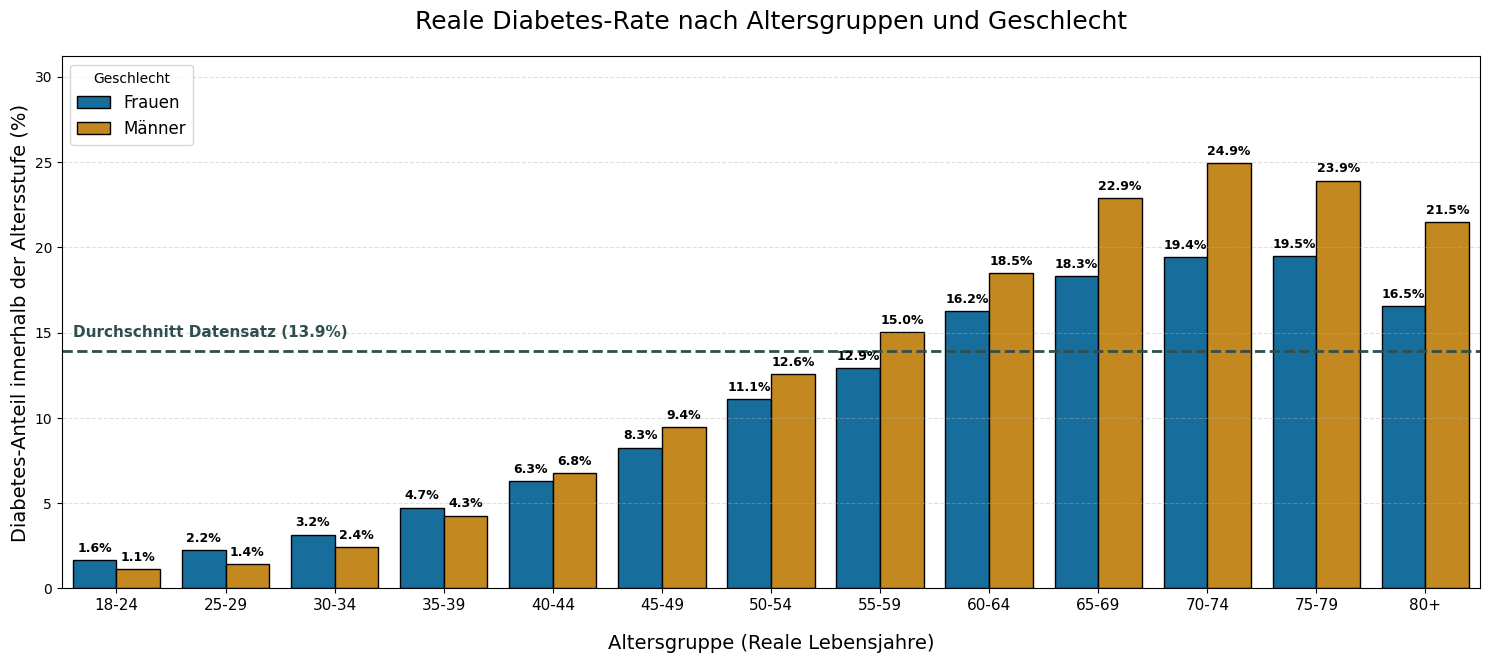

In [415]:

# Grafik: Diabetesrate nach Alter und Geschlecht

# Liste Altersspannen
echte_jahre_labels = [
    "18-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64",
    "65-69",
    "70-74",
    "75-79",
    "80+",
]

# Plot
plt.figure(figsize=(15, 7))

# Gruppiertes Balkendiagramm erzeugen
ax = sns.barplot(
    data=alter_geschlecht_rates,
    x="Altersgruppe",           # Zahlen 1-13 für Positionierung
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
)

# erzwingen der Jahreszahlen als Text unter der Grafik
# 'ticks' nimmt die Positionen der Balken, 'labels' überschreibt sie mit den Texten
plt.xticks(
    ticks=range(len(echte_jahre_labels)),
    labels=echte_jahre_labels,
    rotation=0,
    fontsize=11,
)

# Durchschnitt als "darkslategray" 
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--", linewidth=2)

# Beschriftung ebenfalls in "darkslategray" 
plt.text(
    -0.4,
    baseline_rate + 0.8,
    f"Durchschnitt Datensatz ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontsize=11,
    fontweight="bold",
)

# Styling 
plt.title("Reale Diabetes-Rate nach Altersgruppen und Geschlecht", fontsize=18, pad=20)
plt.xlabel("Altersgruppe (Reale Lebensjahre)", fontsize=14, labelpad=15)
plt.ylabel("Diabetes-Anteil innerhalb der Altersstufe (%)", fontsize=14)

# Y-Achsen-Limit anpassen und genug Raum nach oben
plt.ylim(0, alter_geschlecht_rates["Diabetes_Status"].max() * 1.25)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Legende positionieren
plt.legend(title="Geschlecht", loc="upper left", fontsize=12)

# Prozentzahlen über die Balken schreiben
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=4,
        color="black",
        fontweight="bold",
        fontsize=9,
    )

# Rand-Korrektur für PowerPoint-Export
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()


Cholesterindn und Bluthochdruck nach Geschlechtern


In [418]:
# Berechnung: Bluthochdruck und Cholesterin nach Geschlechtern

# Prozentsatz für hohen Blutdruck nach Geschlecht berechnen
bp_geschlecht = (df.groupby("Geschlecht")["Bluthochdruck"].mean() * 100).reset_index()
bp_geschlecht["Faktor"] = "Bluthochdruck"
bp_geschlecht.rename(columns={"Bluthochdruck": "Anteil"}, inplace=True)

# Prozentsatz für hohes Cholesterin nach Geschlecht berechnen
chol_geschlecht = (df.groupby("Geschlecht")["Cholesterin_hoch"].mean() * 100).reset_index()
chol_geschlecht["Faktor"] = "Hohes Cholesterin"
chol_geschlecht.rename(columns={"Cholesterin_hoch": "Anteil"}, inplace=True)

# Beide Tabellen in einen DF geben
herz_risiko_df = pd.concat([bp_geschlecht, chol_geschlecht], axis=0)

# Numerische Codes (0/1) in Frauen/Männer übersetzen
herz_risiko_df["Geschlecht_Text"] = herz_risiko_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})


# Print
print("Herz-Kreislauf-Risikofaktoren nach Geschlecht")
print()  # Abstandszeile
for index, row in herz_risiko_df.iterrows():
    faktor_name = row["Faktor"]
    geschl = row["Geschlecht_Text"]
    anteil_wert = row["Anteil"]
    # Ausrichtungs für bündige Spalten
    print(f"{faktor_name:<18} | {geschl:<7} | Betroffenheit in der Gruppe: {anteil_wert:.1f}%")



Herz-Kreislauf-Risikofaktoren nach Geschlecht

Bluthochdruck      | Frauen  | Betroffenheit in der Gruppe: 40.6%
Bluthochdruck      | Männer  | Betroffenheit in der Gruppe: 45.8%
Hohes Cholesterin  | Frauen  | Betroffenheit in der Gruppe: 41.0%
Hohes Cholesterin  | Männer  | Betroffenheit in der Gruppe: 44.2%


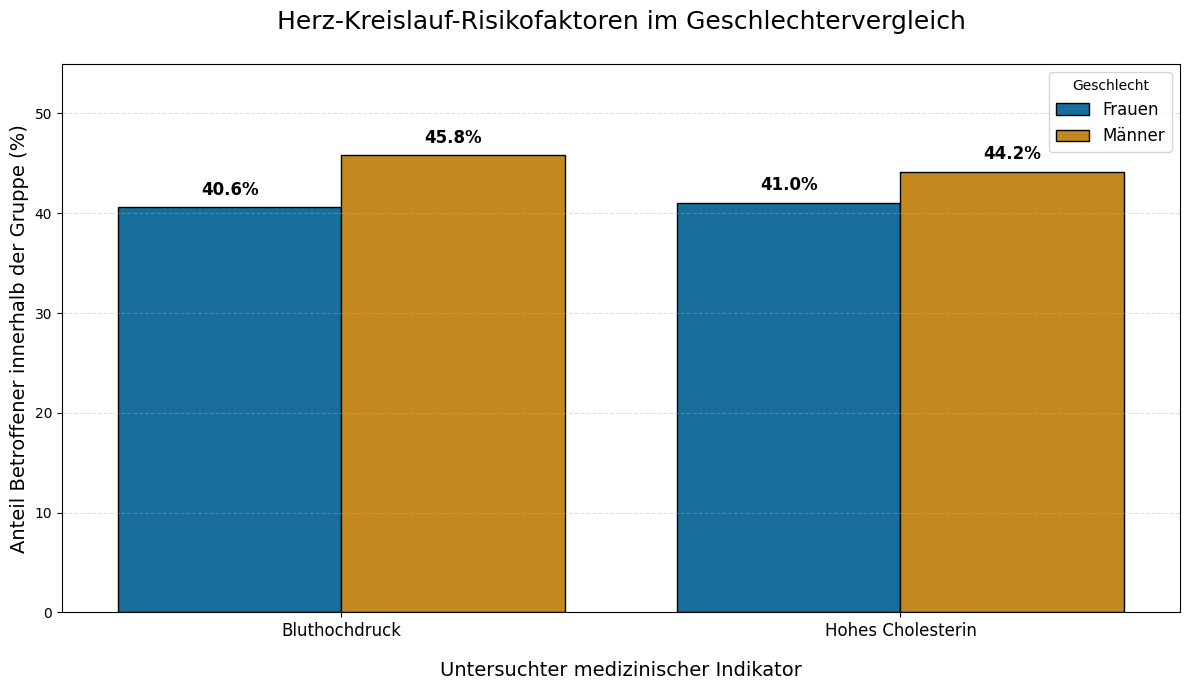

In [422]:
# Grafik: Bluthochdruck und Cholesterin nach Geschlecht

# Plot-Größe festlegen
plt.figure(figsize=(12, 7))

# Gruppiertes Balkendiagramm erzeugen (X-Achse trennt nach Faktoren, Hue nach Geschlecht)
ax = sns.barplot(
    data=herz_risiko_df,
    x="Faktor",
    y="Anteil",
    hue="Geschlecht_Text",
    palette="colorblind",  # Barrierefreies Farbschema 
    edgecolor="black",
)

# Styling 
plt.title(
    "Herz-Kreislauf-Risikofaktoren im Geschlechtervergleich",
    fontsize=18,
    pad=25
)
plt.xlabel("Untersuchter medizinischer Indikator", fontsize=14, labelpad=15)
plt.ylabel("Anteil Betroffener innerhalb der Gruppe (%)", fontsize=14)

# Y-Achsen-Limit leicht erhöhen für genügend Platz
plt.ylim(0, herz_risiko_df["Anteil"].max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Legende positionieren
plt.legend(title="Geschlecht", loc="upper right", fontsize=12)

# Beschriftungen 
plt.xticks(fontsize=12)

# Prozentzahlen automatisch fett über den Balken
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=6,
        color="black",
        fontweight="bold",
        fontsize=12,
    )

# Rand-Korrektur für den PowerPoint-Export
plt.tight_layout()

plt.show()
